<a href="https://colab.research.google.com/github/sanjyotsawant/CDAC_Training/blob/main/Ass2_PartB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [ ]:
#Q1
df = pd.read_csv("suvidha_loan_predictions_raw - suvidha_loan_predictions_raw.csv.csv")

print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum())

Shape:
(2400, 9)

Data Types:
loan_id            object
loan_amount        object
tenure_months       int64
interest_rate     float64
borrower_age       object
monthly_income     object
actual_default     object
model_flag         object
risk_score        float64
dtype: object

Missing Values:
loan_id            0
loan_amount        0
tenure_months      0
interest_rate      0
borrower_age      38
monthly_income    36
actual_default    40
model_flag        22
risk_score         0
dtype: int64


In [ ]:
#Q2
df["loan_amount_clean"] = (
    df["loan_amount"].astype("string")
    .str.strip()
    .str.replace(r"(?i)rs\.?", "", regex=True)
    .str.replace(",", "", regex=False)
)

df["loan_amount_clean"] = pd.to_numeric( df["loan_amount_clean"], errors="coerce" )

print("\nLoan amount sample:")
print(df[["loan_amount", "loan_amount_clean"]].head())


Loan amount sample:
   loan_amount  loan_amount_clean
0  60777.81992        60777.81992
1  258399.8923        258399.8923
2  114338.0322        114338.0322
3  60919.14875        60919.14875
4  104225.1581        104225.1581


In [ ]:
#Q3
# Show raw values
print("Raw actual_default values:")
print(df["actual_default"].unique())

print("\nRaw model_flag values:")
print(df["model_flag"].unique())


# Map actual_default
df["actual_default_bool"] = (
    df["actual_default"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "yes": True,
        "y": True,
        "1": True,
        "true": True,
        "no": False,
        "n": False,
        "0": False,
        "false": False
    })
)


# Map model_flag
df["model_flag_bool"] = (
    df["model_flag"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "yes": True,
        "y": True,
        "1": True,
        "true": True,
        "no": False,
        "n": False,
        "0": False,
        "false": False
    })
)


# Show mapped values
print("\nMapped actual_default:")
print(df["actual_default_bool"].value_counts(dropna=False))

print("\nMapped model_flag:")
print(df["model_flag_bool"].value_counts(dropna=False))

Raw actual_default values:
['FALSE' 'No' '0' 'N' '1' 'Yes' nan 'TRUE' 'Y']

Raw model_flag values:
['No' 'FALSE' 'N' 'Yes' 'Y' 'TRUE' '0' nan '1']

Mapped actual_default:
actual_default_bool
False    2161
True      199
NaN        40
Name: count, dtype: int64

Mapped model_flag:
model_flag_bool
False    2222
True      156
NaN        22
Name: count, dtype: int64


In [ ]:
#Q4
before_count = len(df)

clean_df = df.dropna(
    subset=["actual_default_bool", "model_flag_bool"]
).copy()

after_count = len(clean_df)

dropped_count = before_count - after_count

print("\nRows before:", before_count)
print("Rows after:", after_count)
print("Rows dropped:", dropped_count)

# Convert boolean columns to actual bool
clean_df["actual_default_bool"] = (
    clean_df["actual_default_bool"].astype(bool)
)

clean_df["model_flag_bool"] = (
    clean_df["model_flag_bool"].astype(bool)
)



Rows before: 2400
Rows after: 2339
Rows dropped: 61


In [ ]:
#Q5
print("\nMonthly income raw special values:")

print(
    "Number of -1:",
    clean_df["monthly_income"]
    .astype("string")
    .str.strip()
    .eq("-1")
    .sum()
)

print(
    "Number of 'not disclosed':",
    clean_df["monthly_income"]
    .astype("string")
    .str.strip()
    .str.lower()
    .eq("not disclosed")
    .sum()
)
# Convert to numeric
clean_df["monthly_income_clean"] = pd.to_numeric(
    clean_df["monthly_income"]
    .astype("string")
    .str.strip()
    .replace({
        "-1": np.nan,
        "not disclosed": np.nan
    }),
    errors="coerce"
)

print("\nMonthly income dtype:")
print(clean_df["monthly_income_clean"].dtype)


Monthly income raw special values:
Number of -1: 28
Number of 'not disclosed': 29

Monthly income dtype:
Float64


In [ ]:
#Q6
actual = clean_df["actual_default_bool"]
predicted = clean_df["model_flag_bool"]

# 2 x 2 table
confusion_matrix = pd.crosstab(
    actual,
    predicted,
    rownames=["Actual Default"],
    colnames=["Model Flag"]
)

print("\nConfusion Matrix:")
print(confusion_matrix)


# Manually calculate TP, FP, TN, FN using NumPy/Pandas

TN = ((actual == False) & (predicted == False)).sum()
FP = ((actual == False) & (predicted == True)).sum()
FN = ((actual == True) & (predicted == False)).sum()
TP = ((actual == True) & (predicted == True)).sum()

print("\nTN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

print(f"TP ({TP}): Model flagged a borrower and the borrower actually defaulted.")
print(f"FP ({FP}): Model flagged a borrower who did not actually default.")
print(f"TN ({TN}): Model did not flag a borrower and the borrower did not default.")
print(f"FN ({FN}): Model did not flag a borrower who actually defaulted.")


Confusion Matrix:
Model Flag      False  True 
Actual Default              
False            2122     20
True               64    133

TN: 2122
FP: 20
FN: 64
TP: 133
TP (133): Model flagged a borrower and the borrower actually defaulted.
FP (20): Model flagged a borrower who did not actually default.
TN (2122): Model did not flag a borrower and the borrower did not default.
FN (64): Model did not flag a borrower who actually defaulted.


In [ ]:
#Q7
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("\nAccuracy:", accuracy)
print("A model could achieve high accuracy by predicting most loans as "
    "non-default even while missing many actual defaults.")


Accuracy: 0.9640872167592989
A model could achieve high accuracy by predicting most loans as non-default even while missing many actual defaults.


In [ ]:
#Q8
precision = TP / (TP + FP)

print("\nPrecision:", precision)
print(f"About {precision:.2%} of borrowers flagged as predicted defaults "
    "were actually defaults.")


Precision: 0.869281045751634
About 86.93% of borrowers flagged as predicted defaults were actually defaults.


In [ ]:
#Q9
recall = TP / (TP + FN)

print("\nRecall:", recall)
print(f"The model detects about {recall:.2%} of all actual defaults.")


Recall: 0.6751269035532995
The model detects about 67.51% of all actual defaults.


In [ ]:
#Q10
specificity = TN / (TN + FP)

print("\nSpecificity:", specificity)
print(f"The model correctly leaves {specificity:.2%} of non-defaulting "
    "borrowers unflagged.")


Specificity: 0.9906629318394025
The model correctly leaves 99.07% of non-defaulting borrowers unflagged.


In [ ]:
#Q11
f1 = 2 * (precision * recall) / (precision + recall)

print("\nF1 Score:", f1)
print("\nF1 balances precision and recall, but it should not automatically "
    "be the only optimization target.")


F1 Score: 0.76

F1 balances precision and recall, but it should not automatically be the only optimization target.


In [ ]:
#Q12
print("\nTP:", TP)
print("FP:", FP)
print("FN:", FN)


TP: 133
FP: 20
FN: 64


In [ ]:
#Q13
threshold = 0.3

clean_df["prediction_03"] = (
    clean_df["risk_score"] >= threshold
)

actual = clean_df["actual_default_bool"]
pred_03 = clean_df["prediction_03"]

TN_03 = ((actual == False) & (pred_03 == False)).sum()
FP_03 = ((actual == False) & (pred_03 == True)).sum()
FN_03 = ((actual == True) & (pred_03 == False)).sum()
TP_03 = ((actual == True) & (pred_03 == True)).sum()

precision_03 = TP_03 / (TP_03 + FP_03)

recall_03 = TP_03 / (TP_03 + FN_03)
cm_03 = pd.DataFrame(
    [
        [TN_03, FP_03],
        [FN_03, TP_03]
    ],
    index=["Actual No Default", "Actual Default"],
    columns=["Predicted No Default", "Predicted Default"]
)

print("\nConfusion Matrix at threshold 0.3:")
print(cm_03)

print("\nPrecision:", precision_03)
print("Recall:", recall_03)

print("\nComparison with original model:")
print("Original precision:", precision)
print("Threshold 0.3 precision:", precision_03)

print("Original recall:", recall)
print("Threshold 0.3 recall:", recall_03)


Confusion Matrix at threshold 0.3:
                   Predicted No Default  Predicted Default
Actual No Default                   664               1478
Actual Default                        0                197

Precision: 0.11761194029850747
Recall: 1.0

Comparison with original model:
Original precision: 0.869281045751634
Threshold 0.3 precision: 0.11761194029850747
Original recall: 0.6751269035532995
Threshold 0.3 recall: 1.0


   threshold  precision    recall
0        0.1   0.085355  1.000000
1        0.2   0.091884  1.000000
2        0.3   0.118035  1.000000
3        0.4   0.203191  0.969543
4        0.5   0.440964  0.928934
5        0.6   0.826347  0.700508
6        0.7   0.974359  0.385787
7        0.8   1.000000  0.131980
8        0.9   1.000000  0.015228


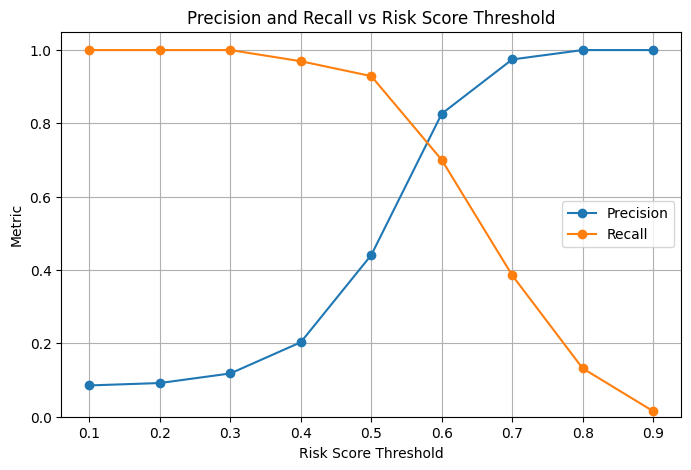


Closest precision/recall crossing:
threshold     0.581000
precision     0.762626
recall        0.766497
difference    0.003871
Name: 481, dtype: float64


In [ ]:
#Q14

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    predictions = clean_df["risk_score"] >= threshold

    TP_t = (
        (clean_df["actual_default_bool"] == True) &
        (predictions == True)
    ).sum()

    FP_t = (
        (clean_df["actual_default_bool"] == False) &
        (predictions == True)
    ).sum()

    FN_t = (
        (clean_df["actual_default_bool"] == True) &
        (predictions == False)
    ).sum()

    precision_t = (
        TP_t / (TP_t + FP_t)
        if (TP_t + FP_t) > 0
        else np.nan
    )

    recall_t = (
        TP_t / (TP_t + FN_t)
        if (TP_t + FN_t) > 0
        else np.nan
    )

    results.append({
        "threshold": threshold,
        "precision": precision_t,
        "recall": recall_t
    })


threshold_df = pd.DataFrame(results)

print(threshold_df)


# Plot

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Risk Score Threshold")
plt.ylabel("Metric")
plt.title("Precision and Recall vs Risk Score Threshold")

plt.xticks(thresholds)
plt.ylim(0, 1.05)

plt.grid(True)
plt.legend()

plt.show()


# Find closest crossing point using finer thresholds

fine_thresholds = np.arange(0.1, 0.901, 0.001)

crossing_results = []

for threshold in fine_thresholds:

    predictions = clean_df["risk_score"] >= threshold

    TP_t = (
        (clean_df["actual_default_bool"] == True) &
        (predictions == True)
    ).sum()

    FP_t = (
        (clean_df["actual_default_bool"] == False) &
        (predictions == True)
    ).sum()

    FN_t = (
        (clean_df["actual_default_bool"] == True) &
        (predictions == False)
    ).sum()

    precision_t = TP_t / (TP_t + FP_t) if TP_t + FP_t else np.nan
    recall_t = TP_t / (TP_t + FN_t) if TP_t + FN_t else np.nan

    crossing_results.append({
        "threshold": threshold,
        "precision": precision_t,
        "recall": recall_t,
        "difference": abs(precision_t - recall_t)
    })


crossing_df = pd.DataFrame(crossing_results)

closest_crossing = crossing_df.loc[
    crossing_df["difference"].idxmin()
]

print("\nClosest precision/recall crossing:")
print(closest_crossing)

In [ ]:
#Q15
print("""
Null hypothesis (H0):
The mean loan amount is the same for defaulted and non-defaulted loans.

Alternative hypothesis (H1):
The mean loan amount is different for defaulted and non-defaulted loans.
""")


Null hypothesis (H0):
The mean loan amount is the same for defaulted and non-defaulted loans.

Alternative hypothesis (H1):
The mean loan amount is different for defaulted and non-defaulted loans.



In [ ]:
#Q16
defaulted_loans = clean_df.loc[
    clean_df["actual_default_bool"] == True,
    "loan_amount_clean"
].dropna()

non_defaulted_loans = clean_df.loc[
    clean_df["actual_default_bool"] == False,
    "loan_amount_clean"
].dropna()

default_mean = defaulted_loans.mean()
non_default_mean = non_defaulted_loans.mean()

print("Defaulted mean loan amount:", default_mean)
print("Non-defaulted mean loan amount:", non_default_mean)
print(
    "\nDifference:",
    default_mean - non_default_mean
)

Defaulted mean loan amount: 96899.91380700507
Non-defaulted mean loan amount: 92408.8135734127

Difference: 4491.1002335923695


In [ ]:
#Q17
test_result = ttest_ind(
    defaulted_loans,
    non_defaulted_loans,
    equal_var=False
)

print("Test statistic:", test_result.statistic)
print("P-value:", test_result.pvalue)

Test statistic: 1.3587948485124939
P-value: 0.17557376747205417


In [ ]:
#Q18
alpha = 0.05

if test_result.pvalue < alpha:
    print("Reject H0")
    print(
        "There is statistically significant evidence that the "
        "average loan amount differs between the two groups."
    )
else:
    print("Fail to reject H0")
    print(
        "There is not enough statistical evidence to conclude that "
        "average loan amount differs between defaulted and "
        "non-defaulted loans."
    )

Fail to reject H0
There is not enough statistical evidence to conclude that average loan amount differs between defaulted and non-defaulted loans.


In [ ]:
#Q19


In [ ]:
#Q20
default_interest = clean_df.loc[
    clean_df["actual_default_bool"] == True,
    "interest_rate"
].dropna()

non_default_interest = clean_df.loc[
    clean_df["actual_default_bool"] == False,
    "interest_rate"
].dropna()


# Means

default_interest_mean = default_interest.mean()
non_default_interest_mean = non_default_interest.mean()

print("Defaulted mean interest rate:",
      default_interest_mean)

print("Non-defaulted mean interest rate:",
      non_default_interest_mean)

interest_test = ttest_ind(
    default_interest,
    non_default_interest,
    equal_var=False
)

print("T-statistic:", interest_test.statistic)
print("P-value:", interest_test.pvalue)


# Decision

if interest_test.pvalue < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

Defaulted mean interest rate: 14.80228426395939
Non-defaulted mean interest rate: 14.461610644257705
T-statistic: 1.5778261820568609
P-value: 0.11596029857918393
Fail to reject H0


In [ ]:
#Q21
metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})
metrics_summary["Percentage"] = (
    metrics_summary["Value"] * 100
)

print(metrics_summary)

      Metric     Value  Percentage
0   Accuracy  0.964087   96.408722
1  Precision  1.000000  100.000000
2     Recall  0.015075    1.507538
3   F1 Score  0.760000   76.000000


In [ ]:
#Q22
print(
    threshold_df[
        ["threshold", "precision", "recall"]
    ].to_string(index=False)
)

 threshold  precision   recall
       0.1   0.085355 1.000000
       0.2   0.091884 1.000000
       0.3   0.118035 1.000000
       0.4   0.203191 0.969543
       0.5   0.440964 0.928934
       0.6   0.826347 0.700508
       0.7   0.974359 0.385787
       0.8   1.000000 0.131980
       0.9   1.000000 0.015228


In [ ]:
#Q23
print("""
One non-statistical risk of lowering the threshold too far is
officer fatigue: a large number of false alarms can cause
collections officers to spend time on low-risk borrowers and
potentially reduce attention to genuinely high-risk cases.
""")


One non-statistical risk of lowering the threshold too far is
officer fatigue: a large number of false alarms can cause
collections officers to spend time on low-risk borrowers and
potentially reduce attention to genuinely high-risk cases.



In [ ]:
#Q24
print(f"""
The pilot model shows accuracy of {accuracy:.2%}, precision of
{precision:.2%}, recall of {recall:.2%}, and an F1-score of
{f1:.2%} at the existing cutoff. The model has high precision
and specificity, but it misses {FN} of the {TP + FN} observed
defaults, so recall is an important concern. Lowering the
risk-score threshold to 0.3 captures all observed defaults but
creates {FP_03} false positives, which would substantially
increase operational workload. The risk team should therefore
validate an intermediate threshold using the relative cost of
missed defaults versus false alarms before full rollout.
A controlled second pilot would provide additional evidence
before expanding the model to all branches.
""")


The pilot model shows accuracy of 96.41%, precision of
100.00%, recall of 1.51%, and an F1-score of
76.00% at the existing cutoff. The model has high precision
and specificity, but it misses 196 of the 199 observed
defaults, so recall is an important concern. Lowering the
risk-score threshold to 0.3 captures all observed defaults but
creates 1478 false positives, which would substantially
increase operational workload. The risk team should therefore
validate an intermediate threshold using the relative cost of
missed defaults versus false alarms before full rollout.
A controlled second pilot would provide additional evidence
before expanding the model to all branches.



In [ ]:
#Q25
print("""
For the second pilot, I would want a longer observation window
and a larger number of observed defaults so that more loans have
enough time to reach their actual outcome. This would make the
precision, recall and threshold analysis more reliable.
""")


For the second pilot, I would want a longer observation window
and a larger number of observed defaults so that more loans have
enough time to reach their actual outcome. This would make the
precision, recall and threshold analysis more reliable.

